In [56]:
import pandas as pd
import neuron
import random
import matplotlib.pyplot as plt
import numpy as np
import math

data = pd.read_csv("data.csv")

In [6]:
def find_weights_randomly(df, neuron, method):

    solutions = []
    attempts = 0
    max_i = 1000

    while len(solutions) < 3 and attempts < max_i:
        attempts += 1

        w1 = random.random()
        w2 = random.random()
        b = random.random()

        weights = [w1, w2]

        outputs = neuron.calculate_output_for_df(df, weights, b, method)

        if all(outputs[i] == df['label'].iloc[i] for i in range(len(df))):
            solutions.append((weights, b))
            print("Rastas sprendinys:")
            print("Svoriai: ", weights)
            print("Poslinkis:", b)
            print()

    print("Viso bandyta: ", attempts)
    return solutions


In [9]:
perceptron = neuron.Neuron()


print("STEP METODAS\n")
step_solutions = find_weights_randomly(data, perceptron, 'step')
print("SIGMOID METODAS\n")
sigmoid_solutions = find_weights_randomly(data, perceptron, 'sigmoid')

STEP METODAS

Rastas sprendinys:
Svoriai:  [0.10820239022501832, 0.8891469640625165]
Poslinkis: 0.6047496876691666

Rastas sprendinys:
Svoriai:  [0.006925367798434112, 0.8138449716238584]
Poslinkis: 0.4048730171217283

Rastas sprendinys:
Svoriai:  [0.043491260016399025, 0.47790963415456345]
Poslinkis: 0.17271561791713497

Viso bandyta:  30
SIGMOID METODAS

Rastas sprendinys:
Svoriai:  [0.004741056639249064, 0.36979226223196926]
Poslinkis: 0.5000778920606054

Rastas sprendinys:
Svoriai:  [0.0686876276206777, 0.6740808442748687]
Poslinkis: 0.5943482556161781

Rastas sprendinys:
Svoriai:  [0.0033937874904629295, 0.13857364263622296]
Poslinkis: 0.6646609676740881

Viso bandyta:  16


In [15]:
rows = []
for weights, bias in step_solutions:
    w1 = weights[0]
    w2 = weights[1]
    rows.append({'w1': w1, 'w2': w2, 'bias': bias})

step_solution_df = pd.DataFrame(rows)

rows = []
for weights, bias in sigmoid_solutions:
    w1 = weights[0]
    w2 = weights[1]
    rows.append({'w1': w1, 'w2': w2, 'bias': bias})

sigmoid_solution_df = pd.DataFrame(rows)

step_solution_df.to_csv('step_solutions.csv', index=False)
sigmoid_solution_df.to_csv('sigmoid_solutions.csv', index=False)

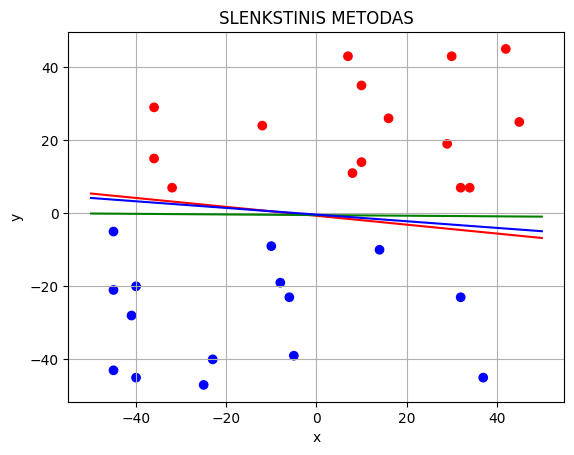

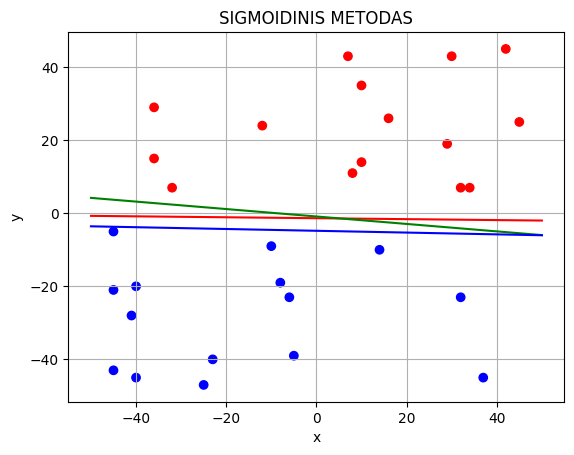

In [ ]:
import pandas as pd
step_solution_df = pd.read_csv('step_solutions.csv')
sigmoid_solution_df = pd.read_csv('sigmoid_solutions.csv')
data = pd.read_csv('data.csv')

plt.scatter(data['x'], data['y'], c=data['label'], cmap='bwr')

x = np.linspace(-50, 50, 100)

colors = ['r', 'g', 'b']

for i, row in step_solution_df.iterrows():
    w1, w2, b = row['w1'], row['w2'], row['bias']
    if w2 != 0:
        y = (-b-w1*x)/w2
        plt.plot(x, y, color=colors[i])
    else:
        print("w2 = 0")
plt.title('SLENKSTINIS METODAS')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

plt.scatter(data['x'], data['y'], c=data['label'], cmap='bwr')

x = np.linspace(-50, 50, 100)

colors = ['r', 'g', 'b']

for i, row in sigmoid_solution_df.iterrows():
    w1, w2, b = row['w1'], row['w2'], row['bias']
    if w2 != 0:
        y = (-b-w1*x)/w2
        plt.plot(x, y, color=colors[i])
    else:
        print("w2 = 0")
plt.title('SIGMOIDINIS METODAS')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


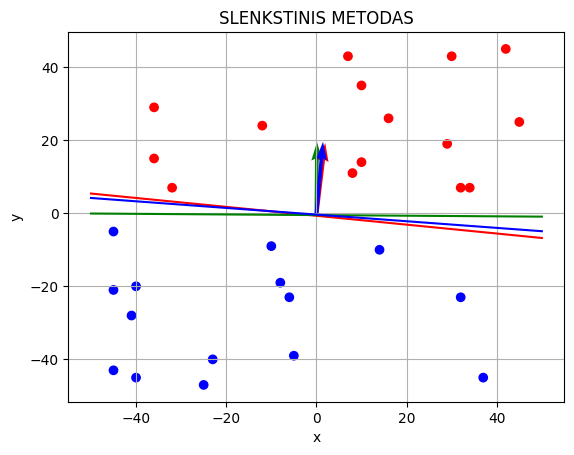

In [59]:
plt.scatter(data['x'], data['y'], c=data['label'], cmap='bwr')

x = np.linspace(-50, 50, 100)

colors = ['r', 'g', 'b']

for i, row in step_solution_df.iterrows():
    w1, w2, b = row['w1'], row['w2'], row['bias']
    if w2 != 0:
        y = (-b-w1*x)/w2
        plt.plot(x, y, color=colors[i])
    else:
        print("w2 = 0")
    if w2 != 0:
        y0 = -b/w2
    else:
        print("w2 = 0")


    length = 20

    norm = math.sqrt(w1**2 + w2**2)

    vx = (w1 / norm) * length
    vy = (w2 / norm) * length

    x0 = 0
    plt.quiver(x0, y0, vx, vy,
            scale_units='xy',
            scale=1,
            color=colors[i])

plt.title('SLENKSTINIS METODAS')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()



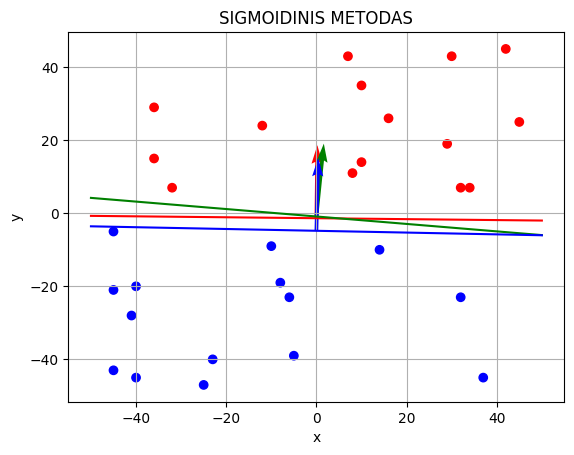

In [60]:
plt.scatter(data['x'], data['y'], c=data['label'], cmap='bwr')

x = np.linspace(-50, 50, 100)

colors = ['r', 'g', 'b']

for i, row in sigmoid_solution_df.iterrows():
    w1, w2, b = row['w1'], row['w2'], row['bias']
    if w2 != 0:
        y = (-b-w1*x)/w2
        plt.plot(x, y, color=colors[i])
    else:
        print("w2 = 0")
    if w2 != 0:
        y0 = -b/w2
    else:
        print("w2 = 0")


    length = 20

    norm = math.sqrt(w1**2 + w2**2)

    vx = (w1 / norm) * length
    vy = (w2 / norm) * length

    x0 = 0
    plt.quiver(x0, y0, vx, vy,
            scale_units='xy',
            scale=1,
            color=colors[i])

plt.title('SIGMOIDINIS METODAS')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

